In [65]:
import os
import shutil
import random
import cv2
import torch
import yaml
from ultralytics import YOLO
from IPython.display import FileLink
import matplotlib.pyplot as plt
import numpy as np


In [66]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")


Using device: cuda


In [68]:
DATA_PATH = '/home/nagaraj/Garbage_classification_files/Garbage classification'
YOLO_DATA_PATH = '/home/nagaraj/Garbage_classification_files/YOLO_Garbage'
VIDEO_OUTPUT = "yolo_demo.mp4"


In [70]:
os.makedirs(YOLO_DATA_PATH, exist_ok=True)
for split in ['train', 'val']:
    os.makedirs(os.path.join(YOLO_DATA_PATH, split), exist_ok=True)

classes = [d for d in os.listdir(DATA_PATH) if os.path.isdir(os.path.join(DATA_PATH,d))]

for cls in classes:
    cls_path = os.path.join(DATA_PATH, cls)
    images = [f for f in os.listdir(cls_path) if f.lower().endswith(('.jpg','.png','.jpeg'))]
    random.shuffle(images)
    n_train = int(0.8*len(images))
    train_imgs = images[:n_train]
    val_imgs = images[n_train:]

    for split, img_list in zip(['train','val'], [train_imgs,val_imgs]):
        cls_split_path = os.path.join(YOLO_DATA_PATH, split, cls)
        os.makedirs(cls_split_path, exist_ok=True)
        for img in img_list:
            shutil.copy(os.path.join(cls_path,img), cls_split_path)

yaml_path = os.path.join(YOLO_DATA_PATH,'data.yaml')
data_yaml = {
    'train': os.path.join(YOLO_DATA_PATH,'train'),
    'val': os.path.join(YOLO_DATA_PATH,'val'),
    'nc': len(classes),
    'names': classes
}
with open(yaml_path,'w') as f:
    yaml.dump(data_yaml,f)
print(f"YOLOv8 dataset & YAML ready: {yaml_path}")


YOLOv8 dataset & YAML ready: /home/nagaraj/Garbage_classification_files/YOLO_Garbage/data.yaml


In [59]:
model = YOLO("yolov8n.pt")  # small model for demo
model.to(device)
print(" YOLOv8 loaded on device:", device)


 YOLOv8 loaded on device: cuda


In [60]:
# Fine-tune on YOLOv8-compatible dataset (optional)
model.train(data=yaml_path, epochs=5, imgsz=640, batch=8, device=device)
print("Fine-tuning complete!")


New https://pypi.org/project/ultralytics/8.3.202 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.201 🚀 Python-3.11.13 torch-2.8.0+cu128 CUDA:0 (NVIDIA GeForce RTX 3080, 9875MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/home/nagaraj/Garbage_classification_files/YOLO_Garbage/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=5, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=Fa

/home/nagaraj/miniconda3/envs/TrajMIA/lib/python3.11/site-packages/ultralytics/nn/modules/block.py:1357: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:233.)
  attn = (q.transpose(-2, -1) @ k) * self.scale
/home/nagaraj/miniconda3/envs/TrajMIA/lib/python3.11/site-packages/ultralytics/nn/modules/block.py:1359: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgor

AMP: checks passed ✅
train: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1175.6±482.0 MB/s, size: 18.9 KB)
train: Scanning /home/nagaraj/Garbage_classification_files/YOLO_Garbage/train/cardboard... 0 images, 2425 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2425/2425 2.2Kit/s 1.1s0.1s
WARNING ⚠️ train: No labels found in /home/nagaraj/Garbage_classification_files/YOLO_Garbage/train/cardboard.cache. See https://docs.ultralytics.com/datasets for dataset formatting guidance.
train: New cache created: /home/nagaraj/Garbage_classification_files/YOLO_Garbage/train/cardboard.cache
WARNING ⚠️ Labels are missing or empty in /home/nagaraj/Garbage_classification_files/YOLO_Garbage/train/cardboard.cache, training may not work correctly. See https://docs.ultralytics.com/datasets for dataset formatting guidance.
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 377.4±105.4 MB/s, size: 18.2 KB)
val: Scanning /home/nagaraj/Garbage_classification_files/YOLO_Garbage/val/cardboard... 0 images, 914 backgroun

/home/nagaraj/miniconda3/envs/TrajMIA/lib/python3.11/site-packages/ultralytics/utils/loss.py:240: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:233.)
  pred_dist = pred_dist.view(b, a, 4, c // 4).softmax(3).matmul(self.proj.type(pred_dist.dtype))


        1/5      1.18G          0      50.53          0          0        640: 100% ━━━━━━━━━━━━ 304/304 10.7it/s 28.3s0.1ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 58/58 21.4it/s 2.7s0.1s
                   all        914          0          0          0          0          0
WARNING ⚠️ no labels found in detect set, can not compute metrics without labels


...

        5/5      1.25G          0       11.2          0          0        640: 100% ━━━━━━━━━━━━ 304/304 12.8it/s 23.7s<0.1s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 58/58 39.1it/s 1.5s0.1s
                   all        914          0          0          0          0          0
WARNING ⚠️ no labels found in detect set, can not compute metrics without labels


/home/nagaraj/miniconda3/envs/TrajMIA/lib/python3.11/site-packages/ultralytics/utils/metrics.py:850: RuntimeWarning: Mean of empty slice.
  i = smooth(f1_curve.mean(0), 0.1).argmax()  # max F1 index
/home/nagaraj/miniconda3/envs/TrajMIA/lib/python3.11/site-packages/numpy/_core/_methods.py:130: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(



5 epochs completed in 0.038 hours.
Optimizer stripped from /home/nagaraj/runs/detect/train2/weights/last.pt, 6.2MB
Optimizer stripped from /home/nagaraj/runs/detect/train2/weights/best.pt, 6.2MB

Validating /home/nagaraj/runs/detect/train2/weights/best.pt...
Ultralytics 8.3.201 🚀 Python-3.11.13 torch-2.8.0+cu128 CUDA:0 (NVIDIA GeForce RTX 3080, 9875MiB)
Model summary (fused): 72 layers, 3,006,818 parameters, 0 gradients, 8.1 GFLOPs
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 58/58 48.9it/s 1.2s0.1s


/home/nagaraj/miniconda3/envs/TrajMIA/lib/python3.11/site-packages/ultralytics/utils/metrics.py:668: RuntimeWarning: Mean of empty slice.
  ax.plot(px, py.mean(1), linewidth=3, color="blue", label=f"all classes {ap[:, 0].mean():.3f} mAP@0.5")
/home/nagaraj/miniconda3/envs/TrajMIA/lib/python3.11/site-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/home/nagaraj/miniconda3/envs/TrajMIA/lib/python3.11/site-packages/ultralytics/utils/metrics.py:713: RuntimeWarning: Mean of empty slice.
  y = smooth(py.mean(0), 0.1)
/home/nagaraj/miniconda3/envs/TrajMIA/lib/python3.11/site-packages/numpy/_core/_methods.py:130: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
/home/nagaraj/miniconda3/envs/TrajMIA/lib/python3.11/site-packages/ultralytics/utils/metrics.py:713: RuntimeWarning: Mean of empty slice.
  y = smooth(py.mean(0), 0.1)
/home/nagaraj/miniconda3/envs/TrajMIA/lib/python3.11/site

                   all        914          0          0          0          0          0
WARNING ⚠️ no labels found in detect set, can not compute metrics without labels
Speed: 0.1ms preprocess, 0.7ms inference, 0.0ms loss, 0.1ms postprocess per image
Results saved to /home/nagaraj/runs/detect/train2
Fine-tuning complete!


In [61]:
sample_images = []
for root, _, files in os.walk(YOLO_DATA_PATH):
    for file in files:
        if file.lower().endswith(('.jpg','.jpeg','.png')):
            sample_images.append(os.path.join(root,file))
    if len(sample_images) >= 50:
        break

sample_images = random.sample(sample_images, min(30, len(sample_images)))
print(f" Selected {len(sample_images)} images for demo.")


 Selected 30 images for demo.


In [72]:
video_frames = []
for idx, img_path in enumerate(sample_images, start=1):
    results = model(img_path, device=device)
    annotated = results[0].plot()
    cv2.putText(annotated, f"Frame {idx}", (10,30), cv2.FONT_HERSHEY_SIMPLEX,1,(0,255,0),2)
    video_frames.append(annotated)
print(" Inference complete")



image 1/1 /home/nagaraj/Garbage_classification_files/YOLO_Garbage/train/glass/glass465.jpg: 480x640 (no detections), 12.4ms
Speed: 4.6ms preprocess, 12.4ms inference, 1.0ms postprocess per image at shape (1, 3, 480, 640)

image 1/1 /home/nagaraj/Garbage_classification_files/YOLO_Garbage/train/glass/glass87.jpg: 480x640 (no detections), 7.9ms
Speed: 2.6ms preprocess, 7.9ms inference, 0.7ms postprocess per image at shape (1, 3, 480, 640)

image 1/1 /home/nagaraj/Garbage_classification_files/YOLO_Garbage/train/glass/glass345.jpg: 480x640 (no detections), 7.6ms
Speed: 2.2ms preprocess, 7.6ms inference, 0.7ms postprocess per image at shape (1, 3, 480, 640)

image 1/1 /home/nagaraj/Garbage_classification_files/YOLO_Garbage/train/glass/glass391.jpg: 480x640 (no detections), 7.5ms
Speed: 2.2ms preprocess, 7.5ms inference, 0.7ms postprocess per image at shape (1, 3, 480, 640)

image 1/1 /home/nagaraj/Garbage_classification_files/YOLO_Garbage/train/glass/glass413.jpg: 480x640 (no detections), 7

In [73]:
h, w, _ = video_frames[0].shape
out_video = cv2.VideoWriter(VIDEO_OUTPUT, cv2.VideoWriter_fourcc(*"mp4v"), 5, (w,h))
for frame in video_frames:
    out_video.write(frame)
out_video.release()
print(f"Video saved: {VIDEO_OUTPUT}")
FileLink(VIDEO_OUTPUT)


Video saved: yolo_demo.mp4


/home/nagaraj/yolo_demo.mp4

In [90]:
def visualize_yolo_features(img_path, yolo_model, layer_idx=0):
  
    import torch
    import cv2
    import matplotlib.pyplot as plt

    # Load image
    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    x = torch.from_numpy(img_rgb).permute(2,0,1).unsqueeze(0).float()/255.0
    x = x.to(next(yolo_model.model.parameters()).device)

    feature_maps = []

    def hook(module, input, output):
        feature_maps.append(output)

    # Get backbone layers as list
    layers_list = list(yolo_model.model.model.children())
    target_layer = layers_list[layer_idx]
    handle = target_layer.register_forward_hook(hook)

    # Forward pass
    with torch.no_grad():
        _ = yolo_model.model(x)

    handle.remove()

    if len(feature_maps) == 0:
        print("No feature maps captured!")
        return

    feat = feature_maps[0]  # [1, C, H, W]

    # Visualize first 16 channels
    fig, axes = plt.subplots(4,4,figsize=(10,10))
    for i, ax in enumerate(axes.flat):
        if i < feat.shape[1]:
            ax.imshow(feat[0,i].cpu(), cmap='viridis')
        ax.axis('off')
    plt.show()


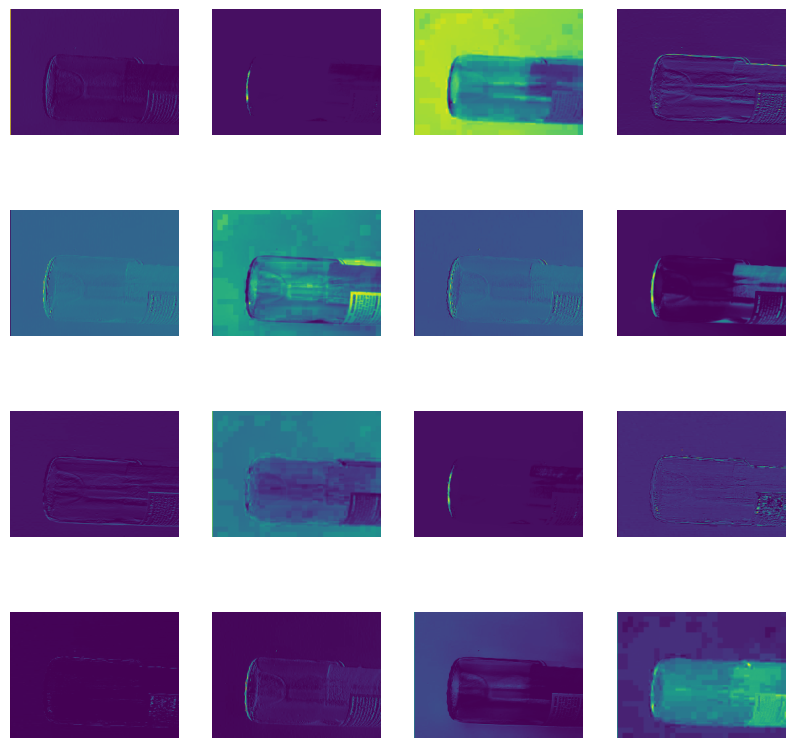

In [91]:
visualize_yolo_features(sample_images[0], model, layer_idx=0)


In [98]:
def guided_backprop_grid(img_path, model, layer_idx=0, rows=10, cols=3):
    """
    Guided Backpropagation visualization for YOLOv8.
    Displays a grid of feature maps for randomly selected neurons (channels) 
    in the specified backbone layer.
    """
    import cv2
    import torch
    import matplotlib.pyplot as plt
    import random
    import numpy as np

    # Load image and preprocess
    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    x = torch.from_numpy(img_rgb).permute(2,0,1).unsqueeze(0).float()/255.0
    x = x.to(next(model.model.parameters()).device)

    # Get backbone layers
    backbone_layers = list(model.model.model.children())
    layer = backbone_layers[layer_idx]

    # Determine number of channels
    try:
        n_channels = layer.conv.out_channels  # For Conv layers
    except AttributeError:
        n_channels = 16  # fallback
        print(f"⚠️ Layer {layer_idx} has no 'conv.out_channels'. Using {n_channels} channels.")

    # Ensure we don't sample more neurons than available channels
    n_neurons = min(n_channels, rows*cols)
    neurons = random.sample(range(n_channels), n_neurons)

    # Guided Backprop helper class
    class GuidedBackpropNeuron:
        def __init__(self, model):
            self.model = model.model
            self.device = next(self.model.parameters()).device
            self.hooks = []
            for module in self.model.modules():
                if isinstance(module, torch.nn.ReLU):
                    self.hooks.append(module.register_forward_hook(self.relu_hook))

        def relu_hook(self, module, input, output):
            return torch.clamp(output, min=0.0)

        def generate_gradients(self, input_image, neuron_idx):
            input_image = input_image.clone().to(self.device)
            input_image.requires_grad = True

            feature_maps = []

            def hook_fn(module, input, output):
                feature_maps.append(output)

            # Register hook on target layer
            h = list(self.model.model.children())[layer_idx].register_forward_hook(hook_fn)
            _ = self.model(input_image)
            h.remove()

            # Select neuron feature map
            feat = feature_maps[0][0, neuron_idx]
            grad = torch.autograd.grad(feat.sum(), input_image)[0]  # [1,3,H,W]
            grad_image = grad[0].cpu().numpy()  # [3,H,W]
            grad_image = np.transpose(grad_image, (1,2,0))  # [H,W,3]
            return grad_image

        def remove_hooks(self):
            for h in self.hooks:
                h.remove()

    gbp = GuidedBackpropNeuron(model)

    # Plot grid
    fig, axes = plt.subplots(rows, cols, figsize=(cols*3, rows*3))
    for i, ax in enumerate(axes.flat):
        if i < n_neurons:
            neuron = neurons[i]
            grad_image = gbp.generate_gradients(x, neuron)
            grad_image -= grad_image.min()
            grad_image /= grad_image.max()
            ax.imshow(grad_image)
            ax.set_title(f"Neuron {neuron}")
        ax.axis('off')

    gbp.remove_hooks()
    plt.tight_layout()
    plt.show()


In [103]:
def guided_backprop_grid(img_path, model, layer_idx=0, rows=10, cols=3):
    import cv2
    import torch
    import matplotlib.pyplot as plt
    import random
    import numpy as np

    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    x = torch.from_numpy(img_rgb).permute(2,0,1).unsqueeze(0).float()/255.0
    x = x.to(next(model.model.parameters()).device)

    backbone_layers = list(model.model.model.children())
    layer = backbone_layers[layer_idx]

    try:
        n_channels = layer.conv.out_channels
    except AttributeError:
        n_channels = 16

    n_neurons = min(n_channels, rows*cols)
    neurons = random.sample(range(n_channels), n_neurons)

    class GuidedBackpropNeuron:
        def __init__(self, model):
            self.model = model.model
            self.device = next(self.model.parameters()).device
            self.hooks = []
            for m in self.model.modules():
                if isinstance(m, torch.nn.ReLU):
                    self.hooks.append(m.register_forward_hook(self.relu_hook))

        def relu_hook(self, module, input, output):
            return torch.clamp(output, min=0.0)

        def generate_gradients(self, input_image, neuron_idx):
            input_image = input_image.clone().to(self.device)
            input_image.requires_grad = True
            feature_maps = []

            def hook_fn(module, input, output):
                feature_maps.append(output)

            try:
                h = list(self.model.model.children())[layer_idx].register_forward_hook(hook_fn)
            except:
                return np.zeros_like(input_image[0].cpu().numpy().transpose(1,2,0))

            _ = self.model(input_image)
            h.remove()

            if len(feature_maps)==0:
                return np.zeros_like(input_image[0].cpu().numpy().transpose(1,2,0))

            feat = feature_maps[0][0, neuron_idx]
            grad = torch.autograd.grad(feat.sum(), input_image)[0]
            grad_image = grad[0].cpu().numpy()
            if grad_image.ndim==3:
                grad_image = np.transpose(grad_image, (1,2,0))
            return grad_image

        def remove_hooks(self):
            for h in self.hooks:
                h.remove()

    gbp = GuidedBackpropNeuron(model)
    fig, axes = plt.subplots(rows, cols, figsize=(cols*3, rows*3))
    for i, ax in enumerate(axes.flat):
        if i < n_neurons:
            neuron = neurons[i]
            grad_image = gbp.generate_gradients(x, neuron)
            grad_image -= grad_image.min()
            grad_image /= grad_image.max()
            ax.imshow(grad_image)
            ax.set_title(f"Neuron {neuron}")
        ax.axis('off')
    gbp.remove_hooks()
    plt.tight_layout()
    plt.show()


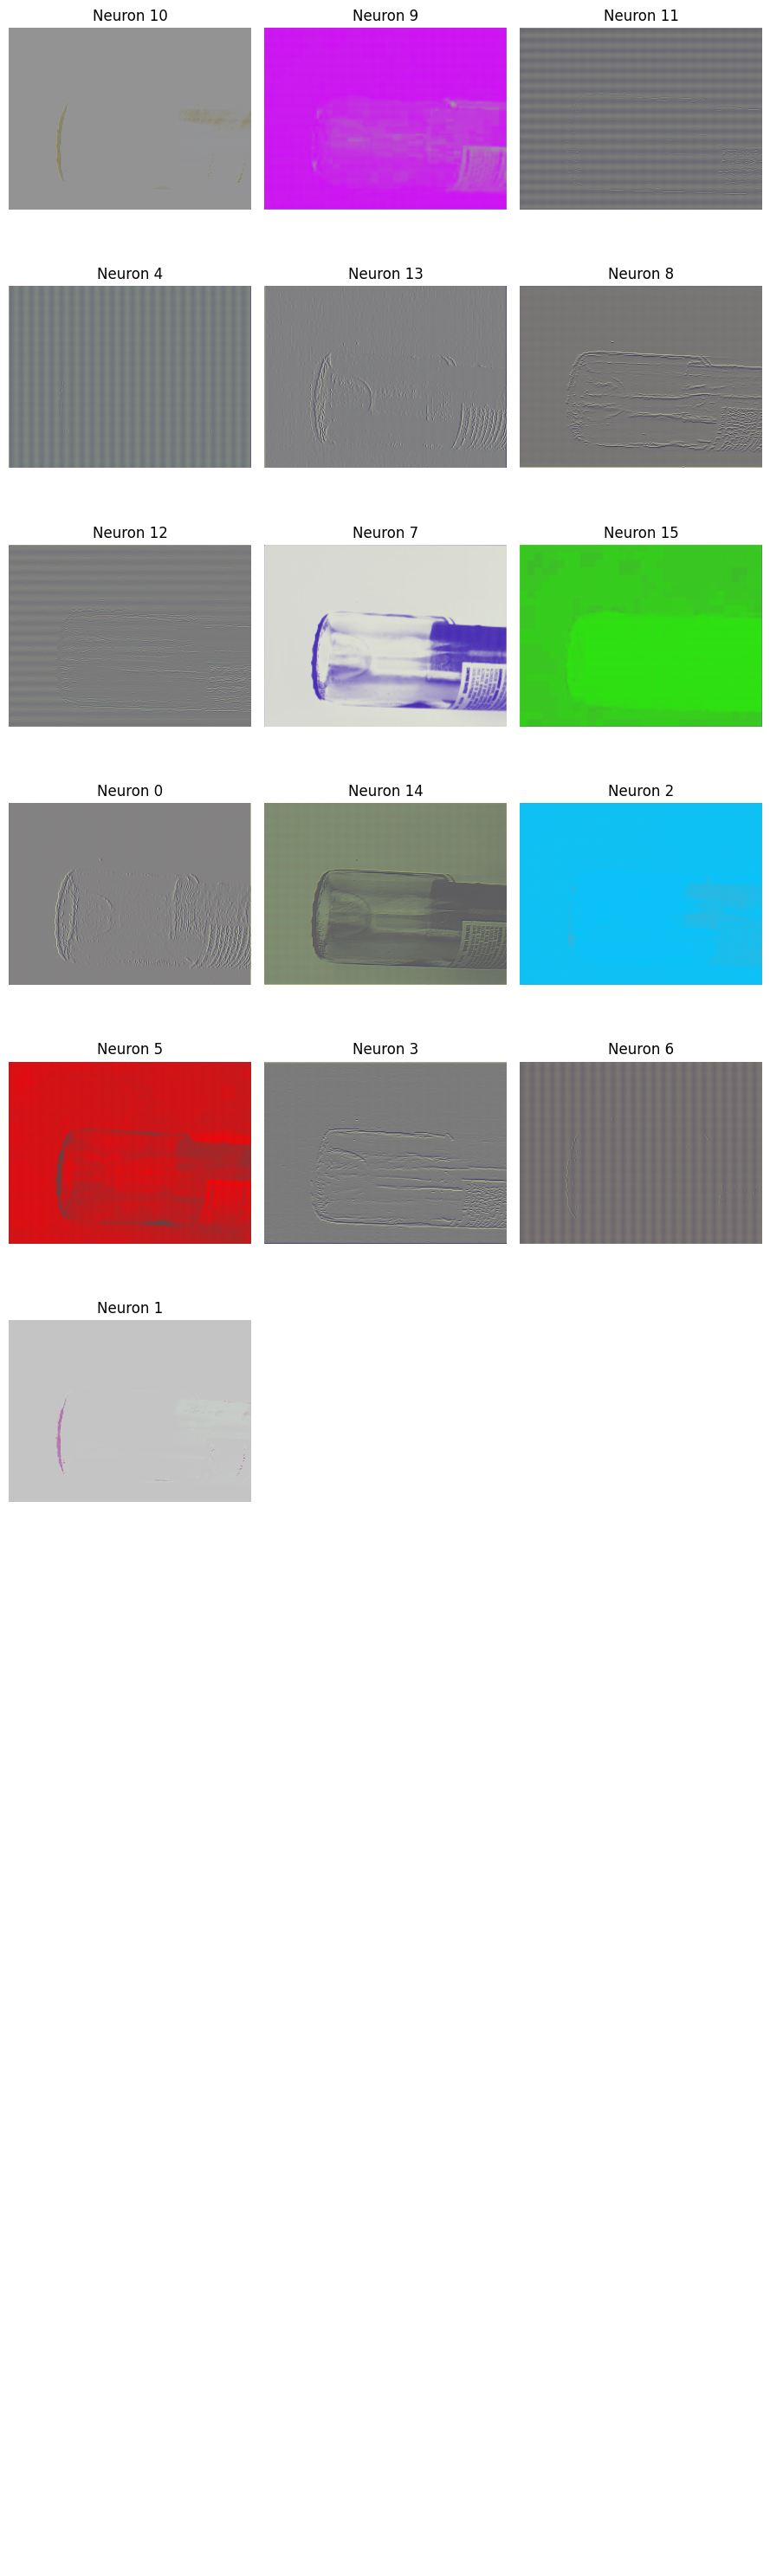

In [104]:
guided_backprop_grid(sample_images[0], model, layer_idx=0, rows=10, cols=3)
